# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [2]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0)
]

In [3]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

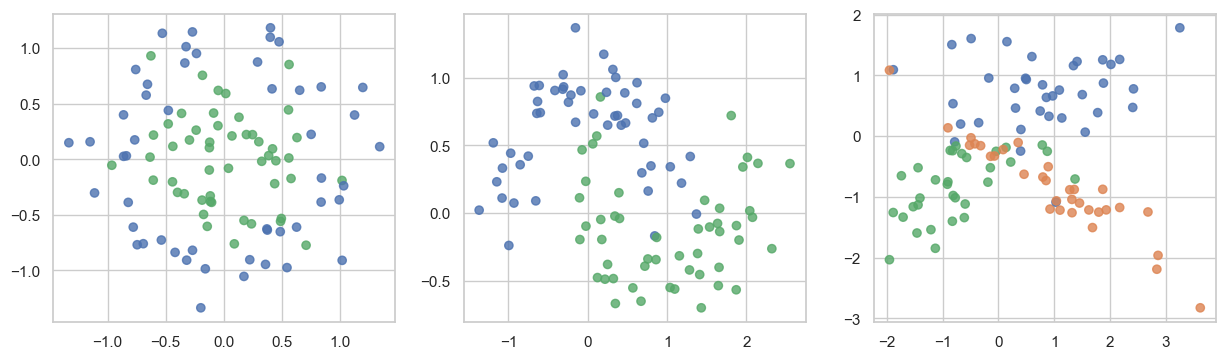

In [4]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [5]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)


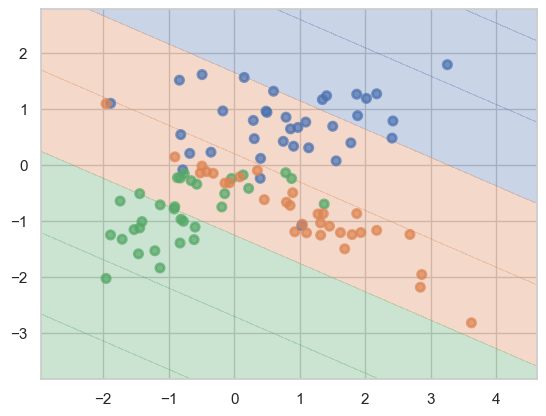

In [6]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

In [7]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

__Ответ:__

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

In [8]:
params_list = [
    {'max_depth': 2, 'name': 'depth 2'},
    {'max_depth': 5, 'name': 'depth 5'},
    {'min_samples_leaf': 10, 'name': 'leaf 10'},
    {'min_samples_leaf': 20, 'name': 'leaf 20'}
]

for dataset_idx, (X, y) in enumerate(datasets):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    print("\nDataset", dataset_idx + 1)

    plt.figure(figsize=(16, 4))

    for i, params in enumerate(params_list):

        param_dict = {k: v for k, v in params.items() if k != 'name'}

        clf = DecisionTreeClassifier(random_state=42, **param_dict)
        clf.fit(X_train, y_train)

        train_acc = accuracy_score(y_train, clf.predict(X_train))
        test_acc = accuracy_score(y_test, clf.predict(X_test))

        plt.subplot(1, 4, i + 1)
        plot_surface(clf, X_test, y_test)

        plt.title(
            params['name'] +
            "\ntrain=" + str(round(train_acc, 3)) +
            " test=" + str(round(test_acc, 3))
        )

        diff = train_acc - test_acc

        print(params['name'])
        print(" train:", round(train_acc, 4))
        print(" test :", round(test_acc, 4))
        print(" delta:", round(diff, 4))
        print()

    plt.tight_layout()
    plt.show()


Dataset 1


NameError: name 'accuracy_score' is not defined

<Figure size 1600x400 with 0 Axes>

__Ответ:__

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

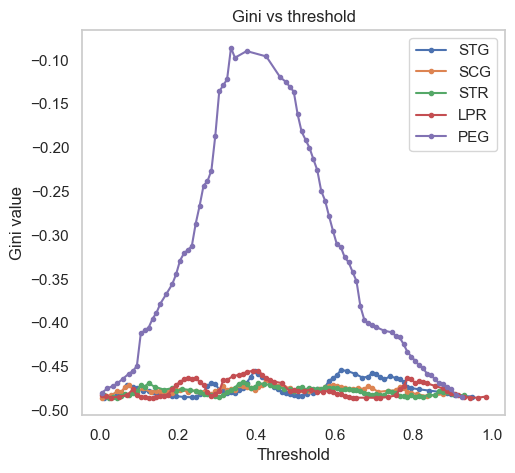

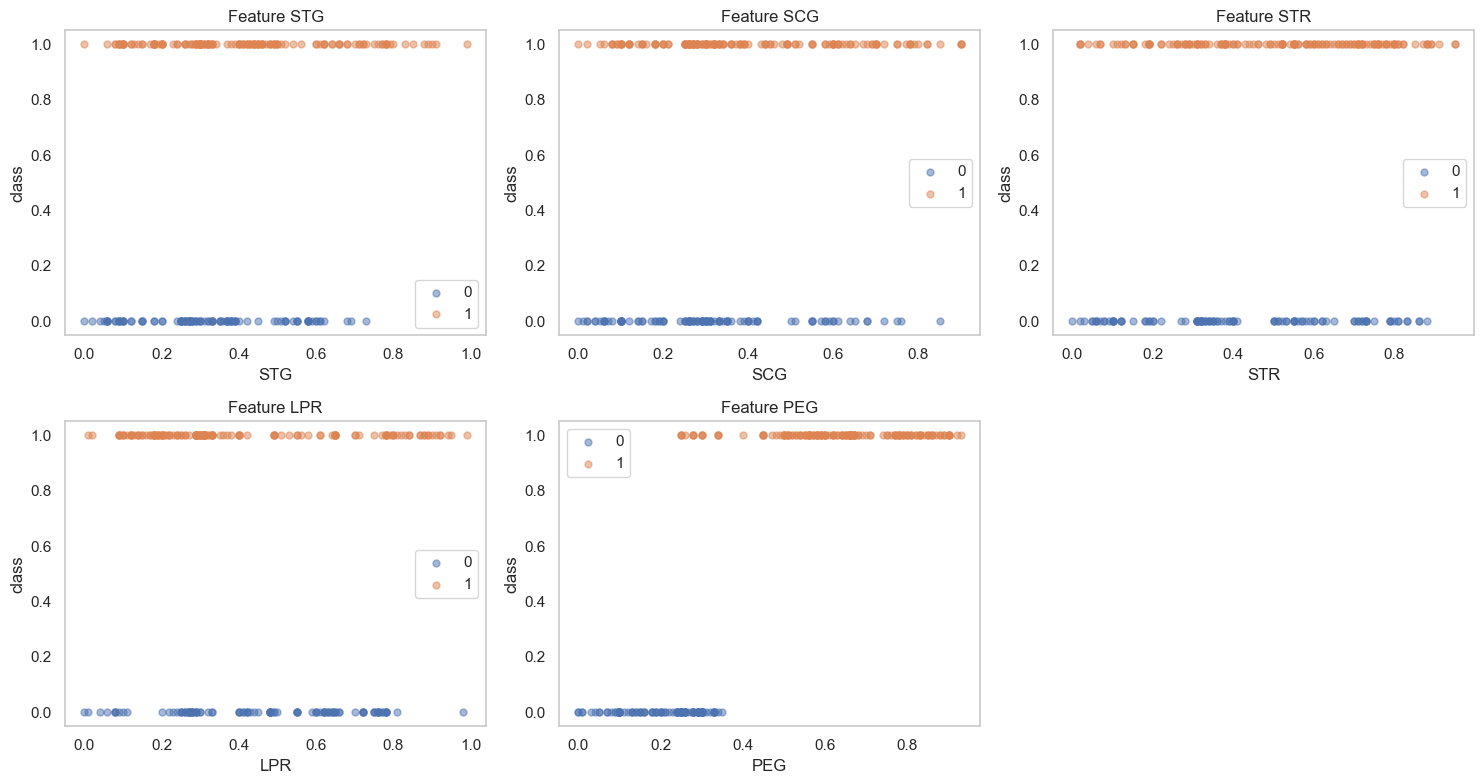

In [ ]:
import pandas as pd
from hw2code import find_best_split

data = pd.read_csv('datasets/students.csv')

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

feature_names = list(data.columns[:-1])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

for i in range(X.shape[1]):

    thresholds, ginis, threshold_best, gini_best = find_best_split(X[:, i], y)

    plt.plot(
        thresholds,
        ginis,
        marker='.',
        label=str(feature_names[i])
    )

plt.xlabel('Threshold')
plt.ylabel('Gini value')
plt.title('Gini vs threshold')
plt.legend()
plt.grid()


fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i in range(X.shape[1]):

    axes[i].scatter(
        X[y == 0, i],
        y[y == 0],
        alpha=0.5,
        s=25,
        label='0'
    )

    axes[i].scatter(
        X[y == 1, i],
        y[y == 1],
        alpha=0.5,
        s=25,
        label='1'
    )

    axes[i].set_xlabel(feature_names[i])
    axes[i].set_ylabel('class')

    axes[i].set_title('Feature ' + str(feature_names[i]))

    axes[i].legend()
    axes[i].grid()

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:** Лучшим признаком для первого разбиения получился PEG, потому что по графику видно, что именно для него критерий Джини меняется сильнее всего. У PEG кривая имеет заметный максимум, а у остальных признаков (STG, SCG, STR, LPR) линии почти ровные и находятся примерно на одном уровне. Это значит, что изменение порога для этих признаков почти не влияет на качество разбиения, поэтому они хуже подходят для построения дерева.
По scatter-графикам тоже видно, что признак PEG лучше разделяет классы: точки разных классов расположены более упорядоченно. У других признаков объекты разных классов сильно перемешаны, поэтому провести границу между ними сложнее.
Вообще хороший признак отличается тем, что для него критерий Джини заметно зависит от порога и имеет выраженный максимум или минимум. Это означает, что можно найти удачное разбиение. Если же признак плохой, то значения критерия почти не меняются, и такой признак плохо разделяет объекты.


__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from hw2code import DecisionTree

data = pd.read_csv('datasets/agaricus-lepiota.data', header=None)

X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

encoder = LabelEncoder()
y = encoder.fit_transform(y)

for i in range(X.shape[1]):
    encoder = LabelEncoder()
    X[:, i] = encoder.fit_transform(X[:, i])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

feature_types = ['categorical'] * X.shape[1]

tree = DecisionTree(feature_types)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

acc = accuracy_score(y_test, y_pred)

correct = np.sum(y_pred == y_test)
total = len(y_test)

print("Accuracy =", round(acc, 4))
print("Correct predictions:", correct)
print("Total objects:", total)
print("Errors:", total - correct)

Accuracy = 1.0
Correct predictions: 4062
Total objects: 4062
Errors: 0


__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [9]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, make_scorer
from sklearn.model_selection import cross_val_score

from hw2code import DecisionTree


def _encode_categories(X):
    X = X.copy()
    for i in range(X.shape[1]):
        X[:, i] = LabelEncoder().fit_transform(X[:, i])
    return X


datasets_dict = {}

data_mush = pd.read_csv('datasets/agaricus-lepiota.data', header=None)
X_mush = data_mush.iloc[:, 1:].values
y_mush = LabelEncoder().fit_transform(data_mush.iloc[:, 0].values)
X_mush = _encode_categories(X_mush)
datasets_dict["mushrooms"] = (X_mush, y_mush)

data_ttt = pd.read_csv('datasets/tic-tac-toe-endgame.csv', header=None)
X_ttt = data_ttt.iloc[:, :-1].values
y_ttt = LabelEncoder().fit_transform(data_ttt.iloc[:, -1].values)
X_ttt = _encode_categories(X_ttt)
datasets_dict["tic-tac-toe"] = (X_ttt, y_ttt)


def _make_ohe():
    try:
        return OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    except TypeError:
        return OneHotEncoder(sparse=False, handle_unknown="ignore")


def test_algorithms(X, y):
    results = {}
    scorer = make_scorer(accuracy_score)

    tree_real = DecisionTree(feature_types=["real"] * X.shape[1])
    scores = cross_val_score(tree_real, X, y, cv=5, scoring=scorer)
    results["DT_real"] = scores.mean()

    tree_cat = DecisionTree(feature_types=["categorical"] * X.shape[1])
    scores = cross_val_score(tree_cat, X, y, cv=5, scoring=scorer)
    results["DT_categorical"] = scores.mean()

    ohe = _make_ohe()
    X_ohe = ohe.fit_transform(X)

    tree_ohe = DecisionTree(feature_types=["real"] * X_ohe.shape[1])
    scores = cross_val_score(tree_ohe, X_ohe, y, cv=5, scoring=scorer)
    results["DT_real_OHE"] = scores.mean()

    from sklearn.tree import DecisionTreeClassifier
    clf = DecisionTreeClassifier(random_state=42)
    scores = cross_val_score(clf, X, y, cv=5, scoring=scorer)
    results["sklearn_DT"] = scores.mean()

    return results


rows = []
for name, (X, y) in datasets_dict.items():
    print("Тестирование:", name)
    res = test_algorithms(X, y)
    rows.append(pd.DataFrame([res], index=[name]))

results_df = pd.concat(rows)
print("\nРезультаты:")
print(results_df)

Тестирование: mushrooms
Тестирование: tic-tac-toe

Результаты:
              DT_real  DT_categorical  DT_real_OHE  sklearn_DT
mushrooms    0.996799        0.988180     0.994335    0.961591
tic-tac-toe  0.410837        0.533666     0.523249    0.685324


__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:**Различия в результатах объясняются тем, что наборы данных имеют разную структуру признаков. В датасете mushrooms признаки в основном бинарные и хорошо разделяют классы, поэтому способ кодирования почти не влияет на итоговое качество. В датасете tic-tac-toe признаки категориальные, и если рассматривать их как вещественные значения, то получается менее корректное разбиение, из-за чего точность становится хуже.
Некоторая случайность в результатах присутствует, потому что используется кросс-валидация и алгоритм дерева решений может работать немного по-разному на разных разбиениях данных. Это можно уменьшить, если задать фиксированный random_state, но в целом на общий результат это влияет не сильно.

Вставьте что угодно, описывающее ваши впечатления от этого задания: